In [1]:
# Kiểm tra môi trường & GPU

import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())

2.21.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
# IMPORT THƯ VIỆN
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Bidirectional, LSTM,
    Dense, Dropout, BatchNormalization, LayerNormalization,
    MultiHeadAttention, Add, GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.optimizers import Adam
print(" Import thư viện thành công!")

 Import thư viện thành công!


In [3]:
# CỐ ĐỊNH HẠT GIỐNG NGẪU NHIÊN — ĐẢM BẢO KẾT QUẢ TÁI LẠP ĐƯỢC
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


##Thu thập dữ liệu

In [ ]:
import os
import pandas as pd

# 1. Liệt kê toàn bộ file trong thư mục D:\BAV\AI để kiểm tra
print(os.listdir(r"D:\BAV\BTL_AI"))

# 2. Khai báo đường dẫn mới trỏ thẳng vào ổ D (Thêm chữ r ở trước)
path = r"D:\BAV\BTL_AI\hanoi_spatio_temporal_advanced.csv"

# 3. Đọc file bằng Pandas (nếu bạn muốn mở và xử lý dữ liệu)
# df = pd.read_csv(path)
# print(df.head())

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
# in 10 dòng đầu
df.head(10)

,Timestamp,District_ID,Latitude,Longitude,Area_Type,Pop_Density,Temperature,Relative_Humidity,Wind_Speed,PM1,PM2.5,UM003,Hour,DayOfWeek,Month
0,2022-01-01 00:00:00,Cau_Giay,21.036,105.795,2,23000,13.9,90,4.7,27.72,46.9,1863.0,0,5,1
1,2022-01-01 01:00:00,Cau_Giay,21.036,105.795,2,23000,14.3,88,4.1,27.72,46.9,1863.0,1,5,1
2,2022-01-01 02:00:00,Cau_Giay,21.036,105.795,2,23000,14.4,87,4.9,27.72,46.9,1863.0,2,5,1
3,2022-01-01 03:00:00,Cau_Giay,21.036,105.795,2,23000,14.8,86,6.0,27.72,46.9,1863.0,3,5,1
4,2022-01-01 04:00:00,Cau_Giay,21.036,105.795,2,23000,14.9,84,5.0,27.72,46.9,1863.0,4,5,1
5,2022-01-01 05:00:00,Cau_Giay,21.036,105.795,2,23000,14.8,85,3.7,27.72,46.9,1863.0,5,5,1
6,2022-01-01 06:00:00,Cau_Giay,21.036,105.795,2,23000,15.1,83,4.5,27.72,46.9,1863.0,6,5,1
7,2022-01-01 07:00:00,Cau_Giay,21.036,105.795,2,23000,15.5,84,5.5,27.72,46.9,1863.0,7,5,1
8,2022-01-01 08:00:00,Cau_Giay,21.036,105.795,2,23000,16.1,80,6.5,27.72,46.9,1863.0,8,5,1
9,2022-01-01 09:00:00,Cau_Giay,21.036,105.795,2,23000,16.8,76,7.7,27.72,46.9,1863.0,9,5,1


In [ ]:
df.shape

(52560, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          52560 non-null  object 
 1   District_ID        52560 non-null  object 
 2   Latitude           52560 non-null  float64
 3   Longitude          52560 non-null  float64
 4   Area_Type          52560 non-null  int64  
 5   Pop_Density        52560 non-null  int64  
 6   Temperature        52560 non-null  float64
 7   Relative_Humidity  52560 non-null  int64  
 8   Wind_Speed         52560 non-null  float64
 9   PM1                52560 non-null  float64
 10  PM2.5              52560 non-null  float64
 11  UM003              52560 non-null  float64
 12  Hour               52560 non-null  int64  
 13  DayOfWeek          52560 non-null  int64  
 14  Month              52560 non-null  int64  
dtypes: float64(7), int64(6), object(2)
memory usage: 6.0+ MB


In [ ]:
df.describe()

,Latitude,Longitude,Area_Type,Pop_Density,Temperature,Relative_Humidity,Wind_Speed,PM1,PM2.5,UM003,Hour,DayOfWeek,Month
count,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
mean,21.102000,105.813000,2.000000,20366.666667,23.984587,78.848345,8.782816,25.488613,43.126747,1713.061530,11.500000,3.006849,6.526027
std,0.110744,0.013638,0.816504,14774.066526,5.638790,14.675132,4.382151,12.343362,20.885564,829.572861,6.922252,2.001719,3.447884
min,21.012000,105.795000,1.000000,1100.000000,6.400000,22.000000,0.000000,0.180000,0.300000,12.000000,0.000000,0.000000,1.000000
25%,21.012000,105.795000,1.000000,1100.000000,20.100000,69.000000,5.500000,17.910000,30.300000,1204.000000,5.750000,1.000000,4.000000
50%,21.036000,105.816000,2.000000,23000.000000,24.900000,81.000000,8.100000,23.820000,40.300000,1601.000000,11.500000,3.000000,7.000000
75%,21.258000,105.828000,3.000000,37000.000000,28.000000,91.000000,11.500000,27.720000,46.900000,1863.000000,17.250000,5.000000,10.000000
max,21.258000,105.828000,3.000000,37000.000000,39.500000,100.000000,34.700000,119.970000,203.000000,8063.000000,23.000000,6.000000,12.000000


##Tiền xử lý dữ liệu

In [ ]:
# Chuyển đổi định dạng thời gian chuẩn
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [ ]:
# Kiểm tra dữ liệu khuyết thiếu
total_nans = df.isnull().sum().sum()
print(f"Tổng số ô bị trống (NaN): {total_nans}")

Tổng số ô bị trống (NaN): 0


In [ ]:
df.isnull()

,Timestamp,District_ID,Latitude,Longitude,Area_Type,Pop_Density,Temperature,Relative_Humidity,Wind_Speed,PM1,PM2.5,UM003,Hour,DayOfWeek,Month
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52555,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
52556,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
52557,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
52558,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Kiểm tra dữ liệu trùng lặp
total_duplicates = df.duplicated().sum()
print(f" Tổng số dòng trùng lặp: {total_duplicates}")

 Tổng số dòng trùng lặp: 0


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
52555,False
52556,False
52557,False
52558,False


In [ ]:
# PHÂN TÁCH DỮ LIỆU THEO KHÔNG GIAN
print("PHÂN TÁCH DỮ LIỆU THEO TRẠM QUAN TRẮC:")
districts = df['District_ID'].unique()

# Tạo một Dictionary để lưu trữ dữ liệu riêng của từng trạm
dict_stations = {}

for station in districts:
    # Lọc dữ liệu theo từng trạm
    df_temp = df[df['District_ID'] == station].copy()

    # Đặt Timestamp làm Index để chuẩn bị cho bài toán Time-Series
    df_temp.set_index('Timestamp', inplace=True)
    df_temp.sort_index(inplace=True)

    # Lưu vào Dictionary
    dict_stations[station] = df_temp

    # In báo cáo
    start_date = df_temp.index.min().strftime('%d/%m/%Y')
    end_date = df_temp.index.max().strftime('%d/%m/%Y')
    print(f" Trạm {station}: {len(df_temp):,} dòng (Từ {start_date} đến {end_date})")

# Ví dụ lấy dữ liệu trạm Cầu Giấy ra để xem thử
print("\n--- BẢN XEM TRƯỚC DỮ LIỆU TRẠM CẦU GIẤY ---")
display(dict_stations['Cau_Giay'].head(3))

PHÂN TÁCH DỮ LIỆU THEO TRẠM QUAN TRẮC:
 Trạm Cau_Giay: 17,520 dòng (Từ 01/01/2022 đến 31/12/2023)
 Trạm Dong_Da: 17,520 dòng (Từ 01/01/2022 đến 31/12/2023)
 Trạm Soc_Son: 17,520 dòng (Từ 01/01/2022 đến 31/12/2023)

--- BẢN XEM TRƯỚC DỮ LIỆU TRẠM CẦU GIẤY ---


,District_ID,Latitude,Longitude,Area_Type,Pop_Density,Temperature,Relative_Humidity,Wind_Speed,PM1,PM2.5,UM003,Hour,DayOfWeek,Month
Timestamp,,,,,,,,,,,,,,
2022-01-01 00:00:00,Cau_Giay,21.036,105.795,2,23000,13.9,90,4.7,27.72,46.9,1863.0,0,5,1
2022-01-01 01:00:00,Cau_Giay,21.036,105.795,2,23000,14.3,88,4.1,27.72,46.9,1863.0,1,5,1
2022-01-01 02:00:00,Cau_Giay,21.036,105.795,2,23000,14.4,87,4.9,27.72,46.9,1863.0,2,5,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Timestamp          52560 non-null  datetime64[ns]
 1   District_ID        52560 non-null  object        
 2   Latitude           52560 non-null  float64       
 3   Longitude          52560 non-null  float64       
 4   Area_Type          52560 non-null  int64         
 5   Pop_Density        52560 non-null  int64         
 6   Temperature        52560 non-null  float64       
 7   Relative_Humidity  52560 non-null  int64         
 8   Wind_Speed         52560 non-null  float64       
 9   PM1                52560 non-null  float64       
 10  PM2.5              52560 non-null  float64       
 11  UM003              52560 non-null  float64       
 12  Hour               52560 non-null  int64         
 13  DayOfWeek          52560 non-null  int64         
 14  Month 

In [ ]:
df.describe()

,Timestamp,Latitude,Longitude,Area_Type,Pop_Density,Temperature,Relative_Humidity,Wind_Speed,PM1,PM2.5,UM003,Hour,DayOfWeek,Month
count,52560,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
mean,2022-12-31 23:30:00,21.102000,105.813000,2.000000,20366.666667,23.984587,78.848345,8.782816,25.488613,43.126747,1713.061530,11.500000,3.006849,6.526027
min,2022-01-01 00:00:00,21.012000,105.795000,1.000000,1100.000000,6.400000,22.000000,0.000000,0.180000,0.300000,12.000000,0.000000,0.000000,1.000000
25%,2022-07-02 11:45:00,21.012000,105.795000,1.000000,1100.000000,20.100000,69.000000,5.500000,17.910000,30.300000,1204.000000,5.750000,1.000000,4.000000
50%,2022-12-31 23:30:00,21.036000,105.816000,2.000000,23000.000000,24.900000,81.000000,8.100000,23.820000,40.300000,1601.000000,11.500000,3.000000,7.000000
75%,2023-07-02 11:15:00,21.258000,105.828000,3.000000,37000.000000,28.000000,91.000000,11.500000,27.720000,46.900000,1863.000000,17.250000,5.000000,10.000000
max,2023-12-31 23:00:00,21.258000,105.828000,3.000000,37000.000000,39.500000,100.000000,34.700000,119.970000,203.000000,8063.000000,23.000000,6.000000,12.000000
std,NaN,0.110744,0.013638,0.816504,14774.066526,5.638790,14.675132,4.382151,12.343362,20.885564,829.572861,6.922252,2.001719,3.447884


##  Feature Engineering & chuẩn bị dữ liệu cho mô hình

In [ ]:
from sklearn.preprocessing import RobustScaler

# --- BƯỚC 1: FEATURE ENGINEERING ---
df_copy = df.copy()

# 1.1 Khai báo Target
TARGET_COL = 'PM2.5'
df_copy['Target_PM2.5_Future'] = df_copy.groupby('District_ID')[TARGET_COL].shift(-1)
df_copy = df_copy.dropna().reset_index(drop=True)

# 1.2 Giữ lại tính năng Cyclical Encoding đỉnh cao (Tuyệt đối không dùng Hour/Month dạng thô)
df_copy['hour_sin']  = np.sin(2 * np.pi * df_copy['Hour'] / 24)
df_copy['hour_cos']  = np.cos(2 * np.pi * df_copy['Hour'] / 24)
df_copy['month_sin'] = np.sin(2 * np.pi * df_copy['Month'] / 12)
df_copy['month_cos'] = np.cos(2 * np.pi * df_copy['Month'] / 12)

# Danh sách features chuẩn (ĐÃ BỔ SUNG PM2.5 VÀ CÁC BIẾN LƯỢNG GIÁC)
features = [
    'Temperature', 'Relative_Humidity', 'Wind_Speed', 'PM1', 'UM003',
    'PM2.5', # BẮT BUỘC PHẢI CÓ
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]
target = 'Target_PM2.5_Future'

In [ ]:
# --- BƯỚC 2: FIT SCALER TRÊN TẬP TRAIN ĐỂ TRÁNH LEAKAGE ---
feature_scaler = RobustScaler()
target_scaler = RobustScaler()

train_dfs = []
for district in df_copy['District_ID'].unique():
    df_dist = df_copy[df_copy['District_ID'] == district].sort_values('Timestamp').copy()
    split_idx = int(len(df_dist) * 0.70) # Lấy 70% làm Train để fit
    train_dfs.append(df_dist.iloc[:split_idx])

df_train_total = pd.concat(train_dfs)
feature_scaler.fit(df_train_total[features])
target_scaler.fit(df_train_total[[target]])

RobustScaler()

In [ ]:
# --- BƯỚC 3: CHIA TẬP (TRAIN/VAL/TEST), SCALE VÀ TẠO SEQUENCE CHUẨN MỰC ---
def create_sequences(X_data, y_data, seq_length=24):
    X_seq, y_seq = [], []
    for i in range(seq_length, len(X_data)):
        X_seq.append(X_data[i-seq_length:i])
        y_seq.append(y_data[i])
    return np.array(X_seq), np.array(y_seq)

SEQ_LENGTH = 24 # Dùng 24h quá khứ đoán giờ tiếp theo

X_train_list, y_train_list = [], []
X_val_list,   y_val_list   = [], []
X_test_list,  y_test_list  = [], []

for district in df_copy['District_ID'].unique():
    df_dist = df_copy[df_copy['District_ID'] == district].sort_values('Timestamp').copy()

    # Chia 3 tập: 70% Train - 15% Val - 15% Test
    n = len(df_dist)
    train_idx = int(n * 0.70)
    val_idx   = int(n * 0.85)

    df_train = df_dist.iloc[:train_idx]
    df_val   = df_dist.iloc[train_idx:val_idx]
    df_test  = df_dist.iloc[val_idx:]

    # Scale độc lập
    X_tr_sc = feature_scaler.transform(df_train[features])
    y_tr_sc = target_scaler.transform(df_train[[target]])

    X_vl_sc = feature_scaler.transform(df_val[features])
    y_vl_sc = target_scaler.transform(df_val[[target]])

    X_te_sc = feature_scaler.transform(df_test[features])
    y_te_sc = target_scaler.transform(df_test[[target]])

    # Tạo Sequence
    X_tr_seq, y_tr_seq = create_sequences(X_tr_sc, y_tr_sc, seq_length=SEQ_LENGTH)
    X_vl_seq, y_vl_seq = create_sequences(X_vl_sc, y_vl_sc, seq_length=SEQ_LENGTH)
    X_te_seq, y_te_seq = create_sequences(X_te_sc, y_te_sc, seq_length=SEQ_LENGTH)

    # Đưa vào list tổng
    X_train_list.append(X_tr_seq); y_train_list.append(y_tr_seq)
    X_val_list.append(X_vl_seq);   y_val_list.append(y_vl_seq)
    X_test_list.append(X_te_seq);  y_test_list.append(y_te_seq)

In [ ]:
# --- BƯỚC 4: GỘP LẠI (VSTACK) THÀNH DATASET TOÀN CỤC ---
X_train = np.vstack(X_train_list); y_train = np.vstack(y_train_list).reshape(-1, 1)
X_val   = np.vstack(X_val_list);   y_val   = np.vstack(y_val_list).reshape(-1, 1)
X_test  = np.vstack(X_test_list);  y_test  = np.vstack(y_test_list).reshape(-1, 1)

print("\n--- HOÀN TẤT CHUẨN BỊ DỮ LIỆU TOÀN CỤC ---")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape  : {X_val.shape} | y_val shape  : {y_val.shape}")
print(f"X_test shape : {X_test.shape} | y_test shape : {y_test.shape}")


--- HOÀN TẤT CHUẨN BỊ DỮ LIỆU TOÀN CỤC ---
X_train shape: (36717, 24, 10) | y_train shape: (36717, 1)
X_val shape  : (7812, 24, 10) | y_val shape  : (7812, 1)
X_test shape : (7812, 24, 10) | y_test shape : (7812, 1)


## Xây dựng mô hình

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Dropout, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay
import tensorflow.keras.backend as K

print(" CELL 1: KHỞI TẠO KIẾN TRÚC CNN-BiLSTM-ATTENTION ")

# 1. Định nghĩa lớp Attention tùy chỉnh
class TemporalAttention(Layer):
    def __init__(self, **kwargs):
        super(TemporalAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super(TemporalAttention, self).build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)

# 2. Xây dựng Kiến trúc mạng Neural
# Lưu ý: X_train đã được tạo từ bước Tiền xử lý Toàn cục trước đó
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

# Trích xuất đặc trưng cục bộ (CNN)
x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(input_layer)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.2)(x)

# Học phụ thuộc chuỗi dài 2 chiều (BiLSTM)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.2)(x)

# Cơ chế tập trung vào thời điểm quan trọng (Attention)
x = TemporalAttention()(x)

# Hồi quy đầu ra (Dense)
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)
output_layer = Dense(1, activation='linear')(x)

model_super = Model(inputs=input_layer, outputs=output_layer)

# 3. Biên dịch mô hình với Cosine Decay
lr_schedule = CosineDecay(0.001, 100 * (len(X_train) // 64))
model_super.compile(optimizer=Adam(learning_rate=lr_schedule), loss='mse', metrics=['mae'])

model_super.summary()

 CELL 1: KHỞI TẠO KIẾN TRÚC CNN-BiLSTM-ATTENTION 


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 24, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 12, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ (None, 128)            │           140 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,333 (282.55 KB)

 Trainable params: 72,333 (282.55 KB)

 Non-trainable params: 0 (0.00 B)

## Huấn luyện mô hình

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np

print(" BẮT ĐẦU HUẤN LUYỆN (GLOBAL TRAINING) ")

# 1. Cấu hình Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_global_CNN_BiLSTM_Attention.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# 2. Bắt đầu huấn luyện
history = model_super.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"\n HUẤN LUYỆN THÀNH CÔNG! Tạ tốt nhất được lưu tại Epoch: {best_epoch}")

 BẮT ĐẦU HUẤN LUYỆN (GLOBAL TRAINING) 
Epoch 1/100
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2136 - mae: 0.6418
Epoch 1: val_loss improved from None to 0.53501, saving model to best_global_CNN_BiLSTM_Attention.keras

Epoch 1: finished saving model to best_global_CNN_BiLSTM_Attention.keras
574/574 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 0.7863 - mae: 0.5212 - val_loss: 0.5350 - val_mae: 0.5402
Epoch 2/100
569/574 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5177 - mae: 0.4151
Epoch 2: val_loss improved from 0.53501 to 0.53168, saving model to best_global_CNN_BiLSTM_Attention.keras

Epoch 2: finished saving model to best_global_CNN_BiLSTM_Attention.keras
574/574 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.5059 - mae: 0.4107 - val_loss: 0.5317 - val_mae: 0.5416
Epoch 3/100
570/574 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4561 - mae: 0.3871
Epoch 3: val_loss improved from 0.53168 to 0.50350, saving model to best_global_CNN_BiLSTM_Attention.keras

Epoch 3: finished saving mo

##Đánh giá mô hình

ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST 
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
 ĐÁNH GIÁ KẾT QUẢ:
- R² Score : 0.9274 
- MAE      : 4.51 µg/m³
- RMSE     : 6.35 µg/m³
- MAPE     : 13.76 %


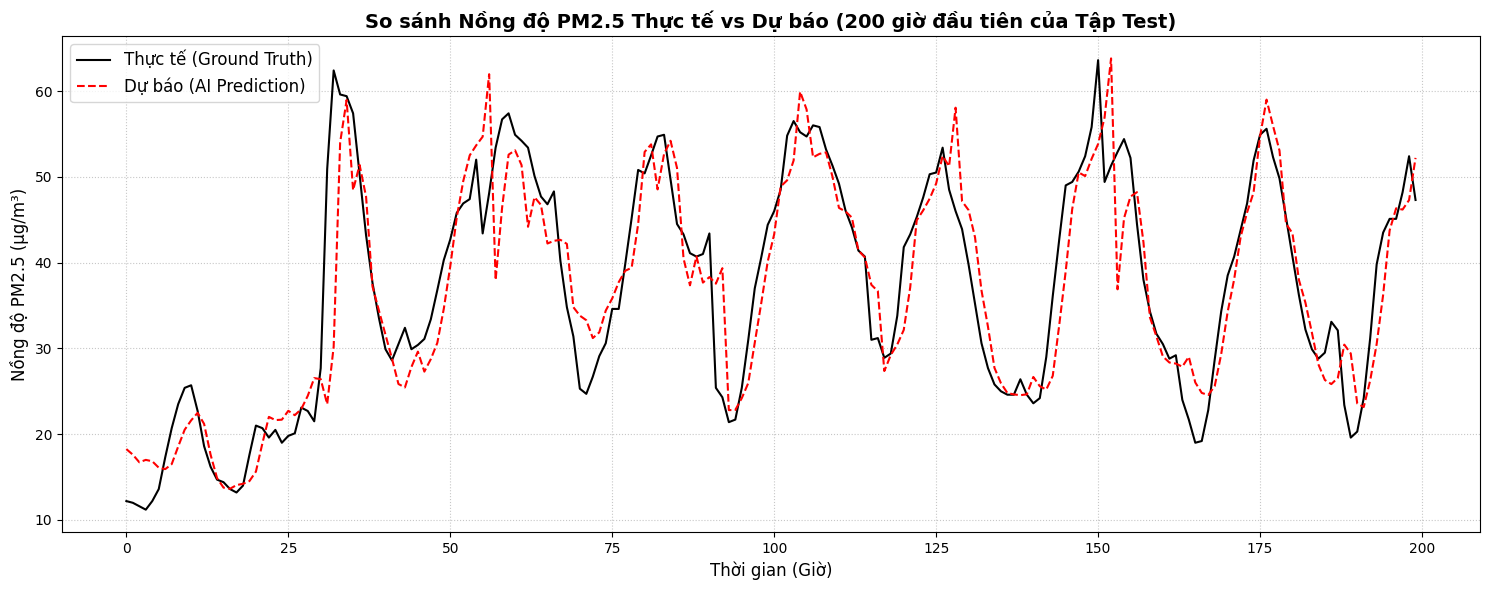

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST ")

# 1. Dự đoán trên tập Test
y_pred_scaled = model_super.predict(X_test)

# 2. Dịch ngược (Inverse Transform) về đơn vị gốc (µg/m³)
# Vì bạn dùng target_scaler (RobustScaler) riêng cho cột PM2.5 nên việc dịch ngược cực kỳ đơn giản
y_pred_real = target_scaler.inverse_transform(y_pred_scaled)
y_test_real = target_scaler.inverse_transform(y_test)

# 3. Tính toán các chỉ số lỗi
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

# Tính MAPE (cộng thêm 1 epsilon nhỏ để tránh lỗi chia cho 0)
mape = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real + 1e-8))) * 100

print(f" ĐÁNH GIÁ KẾT QUẢ:")
print(f"- R² Score : {r2:.4f} ")
print(f"- MAE      : {mae:.2f} µg/m³")
print(f"- RMSE     : {rmse:.2f} µg/m³")
print(f"- MAPE     : {mape:.2f} %")

# 4. Trực quan hóa kết quả (Vẽ 200 giờ đầu tiên của tập Test cho dễ nhìn)
plt.figure(figsize=(15, 6))
plt.plot(y_test_real[:200], label='Thực tế (Ground Truth)', color='black', linewidth=1.5)
plt.plot(y_pred_real[:200], label='Dự báo (AI Prediction)', color='red', linestyle='--', linewidth=1.5)

plt.title('So sánh Nồng độ PM2.5 Thực tế vs Dự báo (200 giờ đầu tiên của Tập Test)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Giờ)', fontsize=12)
plt.ylabel('Nồng độ PM2.5 (µg/m³)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()